# SONATE-2 frames from SatNOGS DB
Every frame ground stations received during our three passes (fetched via the SatNOGS DB API).

In [1]:
import glob, json
import pandas as pd
pd.set_option("display.max_colwidth", 60)

df = pd.read_csv("data/satnogs/sonate2_frames.csv", parse_dates=["timestamp"], dtype={"observation_id": "Int64"})
print(df.shape)
df.head(10)

(2543, 12)


,sat_id,norad_cat_id,transmitter,app_source,decoded,frame,observer,timestamp,version,observation_id,station_id,associated_satellites
0,PBTZ-3525-0189-2410-5216,59112,NaN,network,NaN,86A240404040E088A060A69CB06103F02700353618000864EC4B0073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:18:48+00:00,NaN,15039241,1664.0,['YFDH-6340-5343-3152-5493']
1,PBTZ-3525-0189-2410-5216,59112,NaN,network,NaN,86A240404040E088A060A69CB06103F02700313318000864EC480073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:18:42+00:00,NaN,15039241,1664.0,['YFDH-6340-5343-3152-5493']
2,PBTZ-3525-0189-2410-5216,59112,NaN,network,NaN,86A240404040E088A060A69CB06103F027002F3118000864EC460073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:18:38+00:00,NaN,15039241,1664.0,['YFDH-6340-5343-3152-5493']
3,PBTZ-3525-0189-2410-5216,59112,NaN,network,NaN,86A240404040E088A060A69CB06103F027002D2F18000864EC440073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:18:34+00:00,NaN,15039241,1664.0,['YFDH-6340-5343-3152-5493']
4,PBTZ-3525-0189-2410-5216,59112,NaN,network,NaN,86A240404040E088A060A69CB06103F027002C2E18000864EC430073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:18:32+00:00,NaN,15039241,1664.0,['YFDH-6340-5343-3152-5493']
5,PBTZ-3525-0189-2410-5216,59112,NaN,network,NaN,86A240404040E088A060A69CB06103F027002B2D18000864EC420073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:18:30+00:00,NaN,15039241,1664.0,['YFDH-6340-5343-3152-5493']
6,PBTZ-3525-0189-2410-5216,59112,NaN,network,NaN,86A240404040E088A060A69CB06103F027002A2C18000864EC410073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:18:28+00:00,NaN,15039241,1664.0,['YFDH-6340-5343-3152-5493']
7,PBTZ-3525-0189-2410-5216,59112,NaN,network,NaN,86A240404040E088A060A69CB06103F0270229AC1FFF9E0000000000...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:18:27+00:00,NaN,15039241,1664.0,['YFDH-6340-5343-3152-5493']
8,PBTZ-3525-0189-2410-5216,59112,NaN,network,NaN,86A240404040E088A060A69CB06103F0270228AB1800087AC550006C...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:18:27+00:00,NaN,15039241,1664.0,['YFDH-6340-5343-3152-5493']
9,PBTZ-3525-0189-2410-5216,59112,NaN,network,NaN,86A240404040E088A060A69CB06103F02700272B18000864EC400073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:18:26+00:00,NaN,15039241,1664.0,['YFDH-6340-5343-3152-5493']


## Frames per pass and per ground station

In [2]:
df.groupby(["observation_id", "observer"]).size().rename("frames").to_frame()

,,frames
observation_id,observer,
15036321,DEX-ONE-JO20ul,1
15039241,DK0SB-VHF/UHF-Hi-JO31ok,382
15039527,Astronomiemuseum Turnstile VHF (Test UHF)-JO50oj,3
15039839,PE0SAT-21-JO21mr,63
15039848,PE0SAT-31-JO21mr,3
15039885,ISAE Supaero V/UHF-JN03rn,180
15052725,DK0SB-UHF-Omni-JO31ok,241
15052729,DK0SB-VHF/UHF-Hi-JO31ok,602
15058812,PE0SAT-21-JO21mr,238


## Decode the AX.25 header
Each `frame` is hex. The first 14 bytes are the destination and source callsigns (each character shifted left by 1 bit).

In [3]:
def callsign(b):
    call = "".join(chr(c >> 1) for c in b[:6]).strip()
    ssid = (b[6] >> 1) & 0x0F
    return f"{call}-{ssid}" if ssid else call

raw = df["frame"].apply(bytes.fromhex)
# A few entries from other stations are junk (1-10 bytes), too short to hold a header
ok = raw.apply(len) >= 16
df["dst"] = raw[ok].apply(lambda b: callsign(b[0:7]))
df["src"] = raw[ok].apply(lambda b: callsign(b[7:14]))
df["length"] = raw.apply(len)
df["payload_hex"] = raw.apply(lambda b: b[16:].hex())   # after 14 address bytes + control + PID

df[["timestamp", "observer", "src", "dst", "length", "payload_hex"]].head(10)

,timestamp,observer,src,dst,length,payload_hex
0,2026-09-21 16:18:48+00:00,DK0SB-VHF/UHF-Hi-JO31ok,DP0SNX,CQ,146,2700353618000864ec4b00736ab158e98218540e303f428000000000...
1,2026-09-21 16:18:42+00:00,DK0SB-VHF/UHF-Hi-JO31ok,DP0SNX,CQ,146,2700313318000864ec4800736ab158e382185408303f428000000000...
2,2026-09-21 16:18:38+00:00,DK0SB-VHF/UHF-Hi-JO31ok,DP0SNX,CQ,146,27002f3118000864ec4600736ab158df82185404303f428000000000...
3,2026-09-21 16:18:34+00:00,DK0SB-VHF/UHF-Hi-JO31ok,DP0SNX,CQ,146,27002d2f18000864ec4400736ab158db82185400303f428000000000...
4,2026-09-21 16:18:32+00:00,DK0SB-VHF/UHF-Hi-JO31ok,DP0SNX,CQ,146,27002c2e18000864ec4300736ab158d9821853fe303f428000000000...
5,2026-09-21 16:18:30+00:00,DK0SB-VHF/UHF-Hi-JO31ok,DP0SNX,CQ,146,27002b2d18000864ec4200736ab158d7821853fc303f428000000000...
6,2026-09-21 16:18:28+00:00,DK0SB-VHF/UHF-Hi-JO31ok,DP0SNX,CQ,146,27002a2c18000864ec4100736ab158d5821853fa303f428000000000...
7,2026-09-21 16:18:27+00:00,DK0SB-VHF/UHF-Hi-JO31ok,DP0SNX,CQ,97,270229ac1fff9e000000000000008000000000000000000000000000...
8,2026-09-21 16:18:27+00:00,DK0SB-VHF/UHF-Hi-JO31ok,DP0SNX,CQ,271,270228ab1800087ac550006c6ab158d39efffc00000001fdfc000000...
9,2026-09-21 16:18:26+00:00,DK0SB-VHF/UHF-Hi-JO31ok,DP0SNX,CQ,146,2700272b18000864ec4000736ab158d3821853f8303f428000000000...


In [4]:
print("Unique frames:", df["frame"].nunique(), "of", len(df), "rows")
print("Too short to decode:", (~ok).sum())
df["src"].value_counts(dropna=False)

Unique frames: 1127 of 2543 rows
Too short to decode: 6


src
DP0SNX        2525
DL7NDR           7
NaN              6
pBH\t%-11       1
QV
4O-12        1
5%7-1         1
\*RH
]-12        1
c)z1-12        1
Name: count, dtype: int64

## Cleaning

| Step | Why |
|---|---|
| 1. Drop empty and constant columns | `transmitter`, `decoded` and `version` are (nearly) empty; `sat_id`, `norad_cat_id`, `associated_satellites` are the same in every row |
| 2. Keep only valid SONATE-2 packets | Must be at least 16 bytes, come from `DP0SNX`, and have the AX.25 UI control/PID bytes (`0x03`, `0xF0`). This removes junk from other decoders and ground-station uplinks (DL7NDR) |
| 3. Keep only our three pass windows | The API window can include packets outside the pass times |
| 4. Remove exact duplicate rows | Same packet, same station, same time |
| 5. Build a unique-packet table | Several stations often receive the same packet; one row per distinct packet, with how many stations heard it |

In [5]:
before = len(df)

# 1. Drop empty / constant columns
drop_cols = [c for c in df.columns if df[c].isna().mean() > 0.95 or df[c].nunique(dropna=False) == 1]
clean = df.drop(columns=drop_cols)
print("Dropped columns:", drop_cols)

# 2. Keep only valid SONATE-2 packets
raw = clean["frame"].apply(bytes.fromhex)
valid = (raw.apply(len) >= 16) & (clean["src"] == "DP0SNX") & raw.apply(lambda b: len(b) >= 16 and b[14] == 0x03 and b[15] == 0xF0)
print("Invalid packets removed:", (~valid).sum())
clean = clean[valid]

# 3. Keep only our three pass windows, and label each row with its pass
passes = []
for f in sorted(glob.glob("data/satnogs/sonate2_*/obs.json")):
    o = json.load(open(f))
    passes.append((o["id"], pd.Timestamp(o["start"]), pd.Timestamp(o["end"])))
clean["pass_id"] = pd.NA
for obs_id, start, end in passes:
    clean.loc[clean["timestamp"].between(start, end), "pass_id"] = obs_id
print("Outside pass windows removed:", clean["pass_id"].isna().sum())
clean = clean.dropna(subset=["pass_id"]).astype({"pass_id": "int64"})

# 4. Remove exact duplicate rows
dupes = clean.duplicated(subset=["frame", "observer", "timestamp"])
print("Exact duplicate rows removed:", dupes.sum())
clean = clean[~dupes].sort_values("timestamp").reset_index(drop=True)

print()
print(f"Rows: {before} -> {len(clean)}")
clean.head()

Dropped columns: ['sat_id', 'norad_cat_id', 'transmitter', 'decoded', 'associated_satellites']
Invalid packets removed: 18
Outside pass windows removed: 0
Exact duplicate rows removed: 17

Rows: 2543 -> 2508


,app_source,frame,observer,timestamp,version,observation_id,station_id,dst,src,length,payload_hex,pass_id
0,network,86A240404040E088A060A69CB06103F027009E3218000864EB470073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:10:07+00:00,NaN,15039241,1664.0,CQ,DP0SNX,146,27009e3218000864eb4700736ab156e18218520633ff428000000000...,15039241
1,network,86A240404040E088A060A69CB06103F027009F3318000864EB480073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:10:10+00:00,NaN,15039241,1664.0,CQ,DP0SNX,146,27009f3318000864eb4800736ab156e38218520833ff428000000000...,15039241
2,network,86A240404040E088A060A69CB06103F02702A12F1800087DC3AB0053...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:10:12+00:00,NaN,15039241,1664.0,CQ,DP0SNX,114,2702a12f1800087dc3ab00536ab156e69e0036ec52492f4c2f4c2f4b...,15039241
3,network,86A240404040E088A060A69CB06103F02700A03418000864EB490073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:10:12+00:00,NaN,15039241,1664.0,CQ,DP0SNX,146,2700a03418000864eb4900736ab156e58218520a33ff428000000000...,15039241
4,network,86A240404040E088A060A69CB06103F02700A43718000864EB4C0073...,DK0SB-VHF/UHF-Hi-JO31ok,2026-09-21 16:10:18+00:00,NaN,15039241,1664.0,CQ,DP0SNX,146,2700a43718000864eb4c00736ab156eb8218521033ff428000000000...,15039241


In [6]:
# 5. One row per distinct packet
packets = (clean.groupby("frame")
           .agg(pass_id=("pass_id", "first"),
                first_seen=("timestamp", "min"),
                length=("length", "first"),
                n_stations=("observer", "nunique"),
                stations=("observer", lambda s: ", ".join(sorted(set(x.rsplit("-", 1)[0] for x in s)))),
                payload_hex=("payload_hex", "first"))
           .reset_index()
           .sort_values("first_seen", ignore_index=True))

print("Unique packets per pass:")
print(packets.groupby("pass_id").size())
packets.head()

Unique packets per pass:
pass_id
15039241    384
15052729    602
15104225    128
dtype: int64


,frame,pass_id,first_seen,length,n_stations,stations,payload_hex
0,86A240404040E088A060A69CB06103F027009E3218000864EB470073...,15039241,2026-09-21 16:10:07+00:00,146,1,DK0SB-VHF/UHF-Hi,27009e3218000864eb4700736ab156e18218520633ff428000000000...
1,86A240404040E088A060A69CB06103F027009F3318000864EB480073...,15039241,2026-09-21 16:10:10+00:00,146,1,DK0SB-VHF/UHF-Hi,27009f3318000864eb4800736ab156e38218520833ff428000000000...
2,86A240404040E088A060A69CB06103F02702A12F1800087DC3AB0053...,15039241,2026-09-21 16:10:12+00:00,114,1,DK0SB-VHF/UHF-Hi,2702a12f1800087dc3ab00536ab156e69e0036ec52492f4c2f4c2f4b...
3,86A240404040E088A060A69CB06103F02700A03418000864EB490073...,15039241,2026-09-21 16:10:12+00:00,146,1,DK0SB-VHF/UHF-Hi,2700a03418000864eb4900736ab156e58218520a33ff428000000000...
4,86A240404040E088A060A69CB06103F02700A43718000864EB4C0073...,15039241,2026-09-21 16:10:18+00:00,146,1,DK0SB-VHF/UHF-Hi,2700a43718000864eb4c00736ab156eb8218521033ff428000000000...


In [7]:
clean.to_csv("data/satnogs/sonate2_frames_clean.csv", index=False)
packets.to_csv("data/satnogs/sonate2_packets_unique.csv", index=False)
print("Saved sonate2_frames_clean.csv and sonate2_packets_unique.csv")

Saved sonate2_frames_clean.csv and sonate2_packets_unique.csv

## When packets were received
One dot per packet, for each of our three passes. Each row is a ground station. Gaps are where the signal faded or the satellite was out of view.

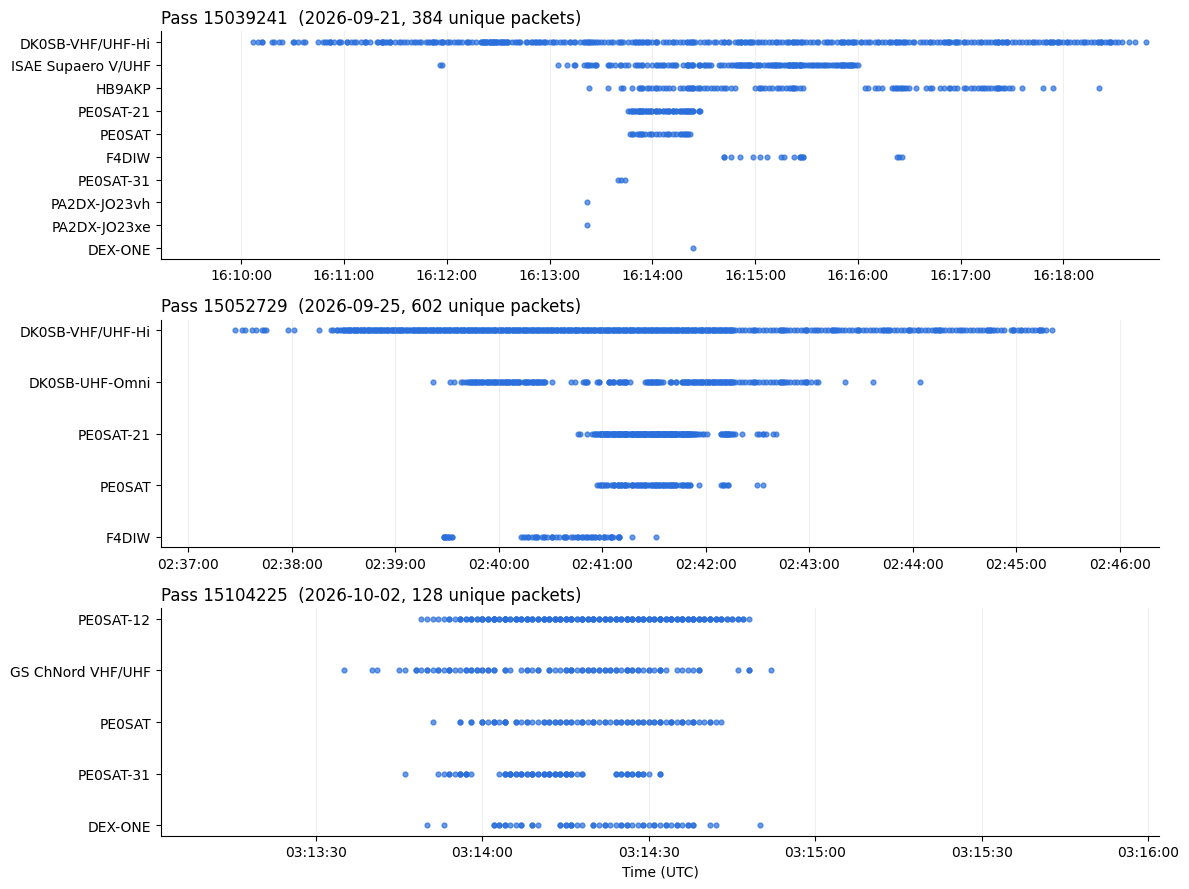

In [8]:
import json, glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sat = clean   # cleaned SONATE-2 packets

fig, axes = plt.subplots(len(passes), 1, figsize=(12, 9))
for ax, (obs_id, start, end) in zip(axes, passes):
    p = sat[(sat["timestamp"] >= start) & (sat["timestamp"] <= end)]
    stations = p["observer"].value_counts().index[::-1]   # busiest station on top
    ypos = {s: k for k, s in enumerate(stations)}
    ax.scatter(p["timestamp"], p["observer"].map(ypos), s=12, color="#2a6fdb", alpha=0.7)
    ax.set_yticks(range(len(stations)))
    short = [s.rsplit("-", 1)[0] for s in stations]   # drop grid locator unless it's needed to tell stations apart
    ax.set_yticklabels([sh if short.count(sh) == 1 else s for sh, s in zip(short, stations)])
    ax.set_xlim(start, end)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.set_title(f"Pass {obs_id}  ({start:%Y-%m-%d}, {p['frame'].nunique()} unique packets)", loc="left")
    ax.grid(axis="x", alpha=0.2)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
axes[-1].set_xlabel("Time (UTC)")
plt.tight_layout()

## Packet sizes
SONATE-2 sends a few fixed packet types, which show up as distinct lengths.

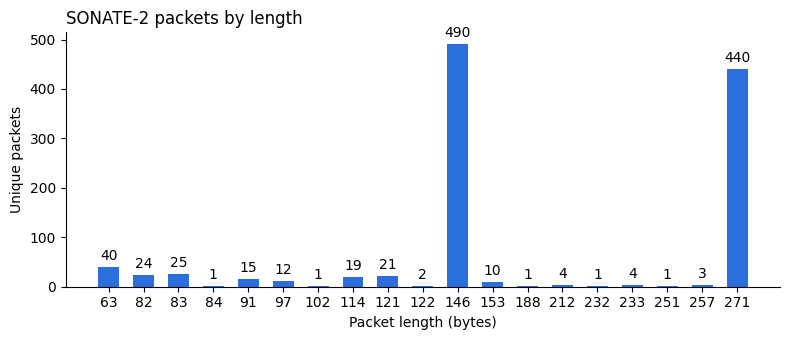

In [9]:
counts = sat.drop_duplicates("frame")["length"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(counts.index.astype(str), counts.values, color="#2a6fdb", width=0.6)
ax.bar_label(bars, padding=3)
ax.set_xlabel("Packet length (bytes)")
ax.set_ylabel("Unique packets")
ax.set_title("SONATE-2 packets by length", loc="left")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
plt.tight_layout()

# Review results
Our decoder's output (`results/`) next to the SatNOGS ground truth. Run `python run_pipeline.py` first.

In [10]:
import pandas as pd
from IPython.display import Image, display

log = pd.read_csv("results/telemetry_log.csv")
truth = pd.read_csv("data/satnogs/sonate2_frames_clean.csv", parse_dates=["timestamp"])

# Payload layout (inferred from the data): byte 0 = 0x27 marker, 1 = packet type, 2 = packet counter, 3 = per-type counter
p = log["payload_hex"].apply(bytes.fromhex)
log["type"] = p.apply(lambda b: b[1] if len(b) > 3 else None)
log["counter"] = p.apply(lambda b: b[2] if len(b) > 3 else None)
log["type_counter"] = p.apply(lambda b: b[3] if len(b) > 3 else None)

log.groupby("pass_id").agg(packets=("frame", "size"),
                           repaired=("corrected_bits", lambda s: (s > 0).sum()),
                           first_s=("audio_time_s", "min"),
                           last_s=("audio_time_s", "max"))

,packets,repaired,first_s,last_s
pass_id,,,,
15039241,265,118,92.415,538.426
15052729,396,192,51.844,506.918
15104225,119,8,44.039,105.190


## Our decoder vs. SatNOGS on the same recording

,pass_id,date,station,satnogs_same_recording,ours,both,only_ours,only_ours_confirmed_by_other_stations,only_satnogs,repaired_by_soft_decision,all_stations_combined
0,15039241,2026-09-21,DK0SB-VHF/UHF-Hi,382,265,265,0,0,117,118,384
1,15052729,2026-09-25,DK0SB-VHF/UHF-Hi,602,396,395,1,0,207,192,602
2,15104225,2026-10-02,PE0SAT-12,110,119,110,9,7,0,8,128


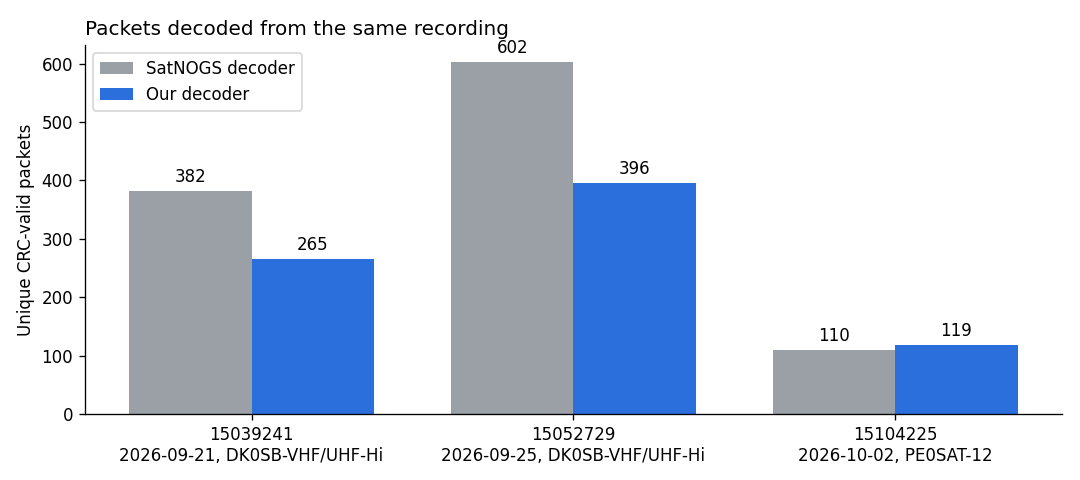

In [11]:
display(pd.read_csv("results/comparison.csv"))
display(Image("results/comparison.png"))

## Ghost frames
CRC-valid packets we decoded that SatNOGS's decoder missed **on the same recording**. `other_stations` shows whether any other ground station received the same packet.

In [12]:
same_rec = set(truth["frame"].where(truth["observation_id"] == truth["pass_id"]).dropna())
ghosts = log[~log["frame"].isin(same_rec)].copy()

def heard_by(frame):
    s = truth.loc[truth["frame"] == frame, "observer"].str.rsplit("-", n=1).str[0]
    return ", ".join(sorted(set(s))) or "none (only us)"

ghosts["other_stations"] = ghosts["frame"].apply(heard_by)
print(len(ghosts), "ghost frames,", (ghosts["corrected_bits"] > 0).sum(), "recovered by bit repair")
ghosts[["pass_id", "utc_approx", "length", "corrected_bits", "counter", "other_stations"]]

10 ghost frames, 8 recovered by bit repair


,pass_id,utc_approx,length,corrected_bits,counter,other_stations
269,15052729,2026-09-25T02:38:34.810000+00:00,271,2,74,none (only us)
661,15104225,2026-10-02T03:13:46.039000+00:00,271,0,253,GS ChNord VHF/UHF
664,15104225,2026-10-02T03:13:48.423000+00:00,146,1,2,"DEX-ONE, GS ChNord VHF/UHF"
665,15104225,2026-10-02T03:13:49.313000+00:00,271,1,3,GS ChNord VHF/UHF
666,15104225,2026-10-02T03:13:49.688000+00:00,271,1,4,none (only us)
668,15104225,2026-10-02T03:13:50.423000+00:00,146,1,6,"GS ChNord VHF/UHF, PE0SAT-31"
674,15104225,2026-10-02T03:13:54.989000+00:00,271,0,14,"GS ChNord VHF/UHF, PE0SAT-31"
677,15104225,2026-10-02T03:13:55.963000+00:00,271,1,17,GS ChNord VHF/UHF
778,15104225,2026-10-02T03:14:46.298000+00:00,146,1,118,GS ChNord VHF/UHF
779,15104225,2026-10-02T03:14:47.190000+00:00,271,1,119,none (only us)


## Packets rescued by bit repair
These failed their checksum at first; flipping the 1–2 least-confident bits made them pass.

In [13]:
rescued = log[log["corrected_bits"] > 0]
print(len(rescued), "of", len(log), f"packets ({100 * len(rescued) / len(log):.0f}%) were rescued")
rescued.groupby(["pass_id", "corrected_bits"]).size().unstack(fill_value=0)

318 of 780 packets (41%) were rescued


corrected_bits,1,2
pass_id,,
15039241,88,30
15052729,142,50
15104225,8,0


## Spot-check any packet
Pick a row and see who else received it.

In [14]:
row = log.iloc[0]   # change the index to check another packet
print(row["utc_approx"], row["length"], "bytes, repaired bits:", row["corrected_bits"])
truth.loc[truth["frame"] == row["frame"], ["timestamp", "observer", "observation_id"]]

2026-09-21T16:10:45.415000+00:00 146 bytes, repaired bits: 0


,timestamp,observer,observation_id
14,2026-09-21 16:10:48+00:00,DK0SB-VHF/UHF-Hi-JO31ok,15039241.0


## Packet loss from the satellite's own counter
Gaps in the counter are packets the satellite sent that we missed.

,pass_id,decoded,counter_says_sent,estimated_loss_pct,all_stations_in_same_span,offset_consistent
0,15039241,265,356,25.6,352,265/265
1,15052729,396,648,38.9,594,395/395
2,15104225,119,123,3.3,120,117/117


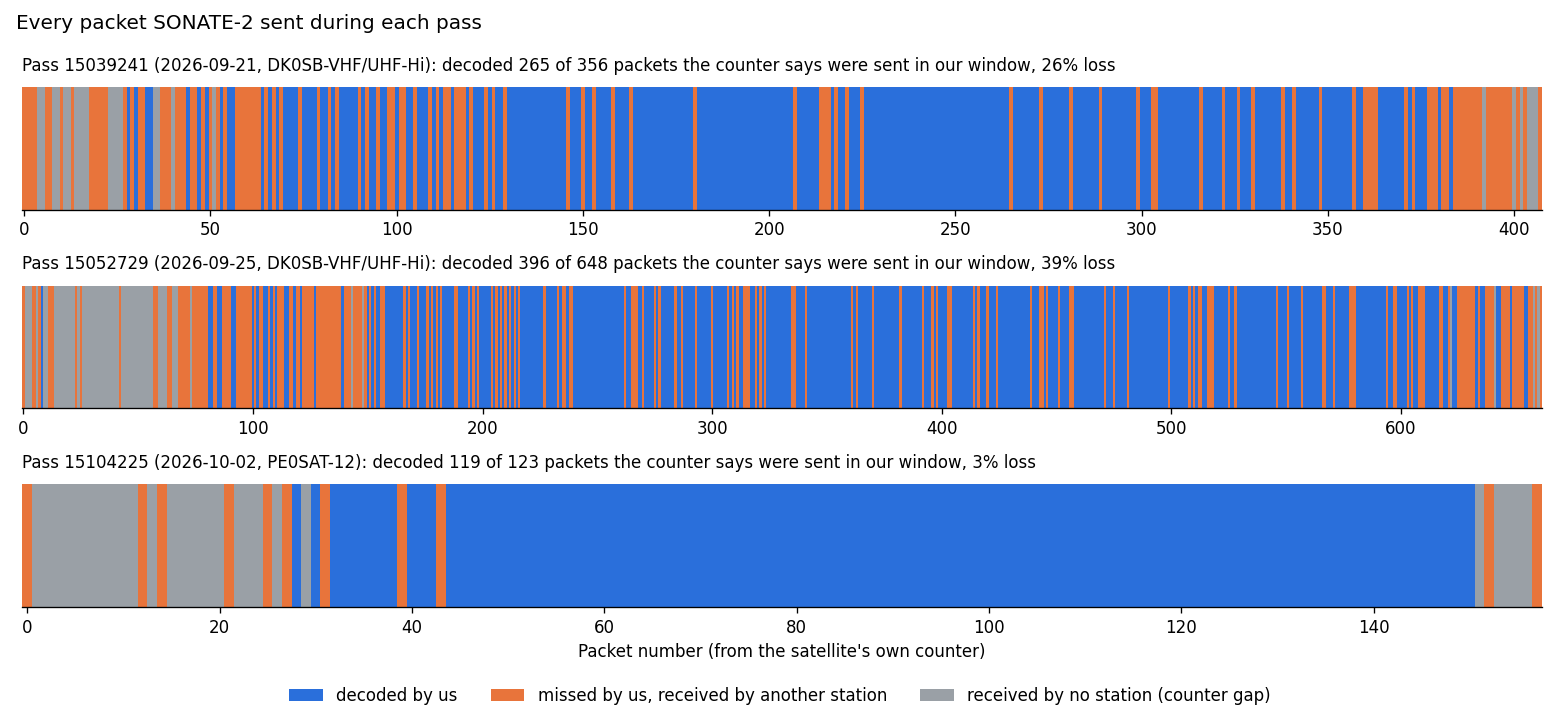

Counter steps on pass 15104225 (1 = no packet missed): {1: 114, 2: 4}


In [15]:
display(pd.read_csv("results/counter_loss.csv"))
display(Image("results/packet_counter.png"))

one = log[log["pass_id"] == 15104225].sort_values("audio_time_s")
steps = (one["counter"].diff() % 256).dropna().astype(int)
print("Counter steps on pass 15104225 (1 = no packet missed):", steps.value_counts().to_dict())

## Plots

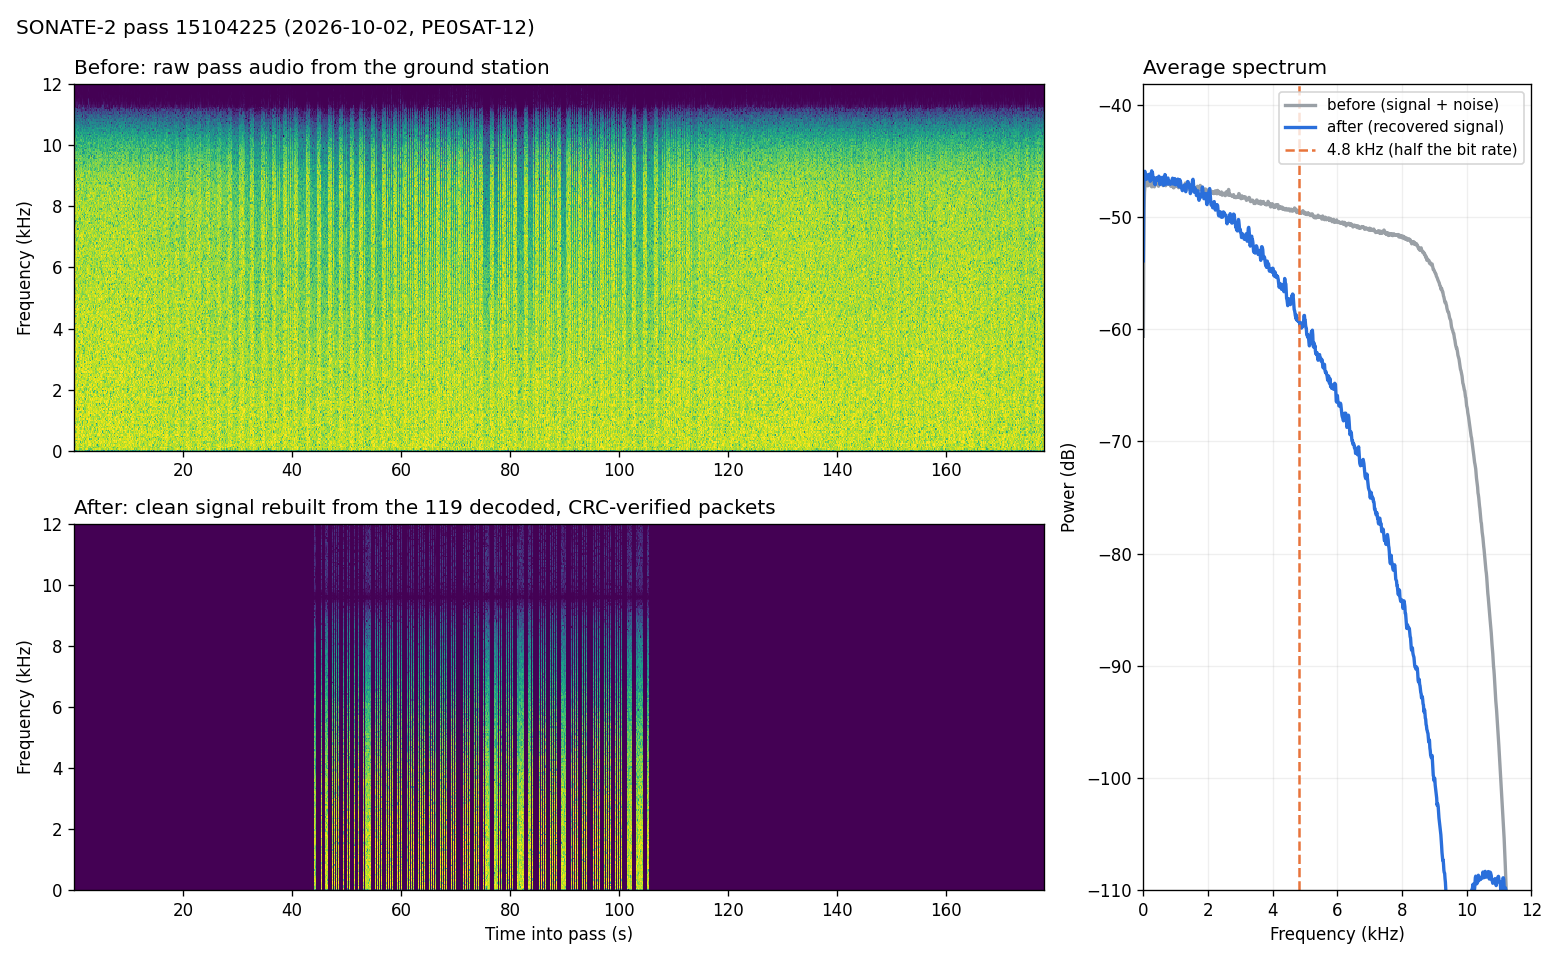

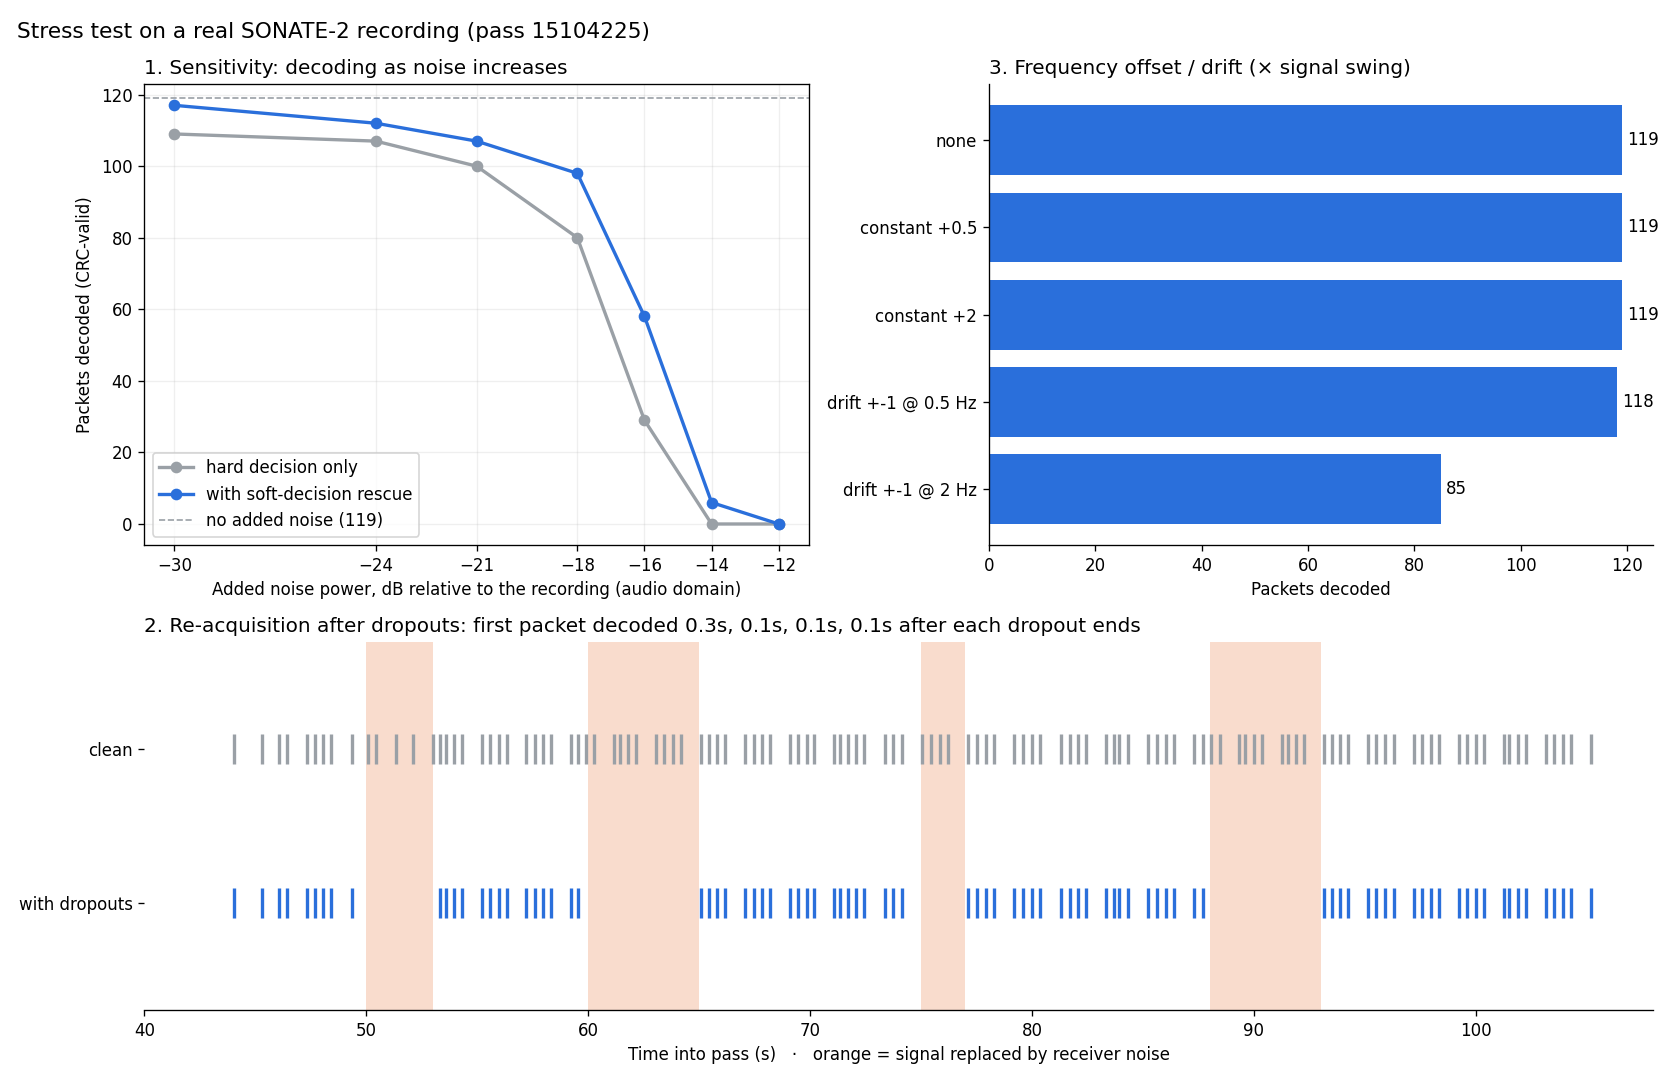

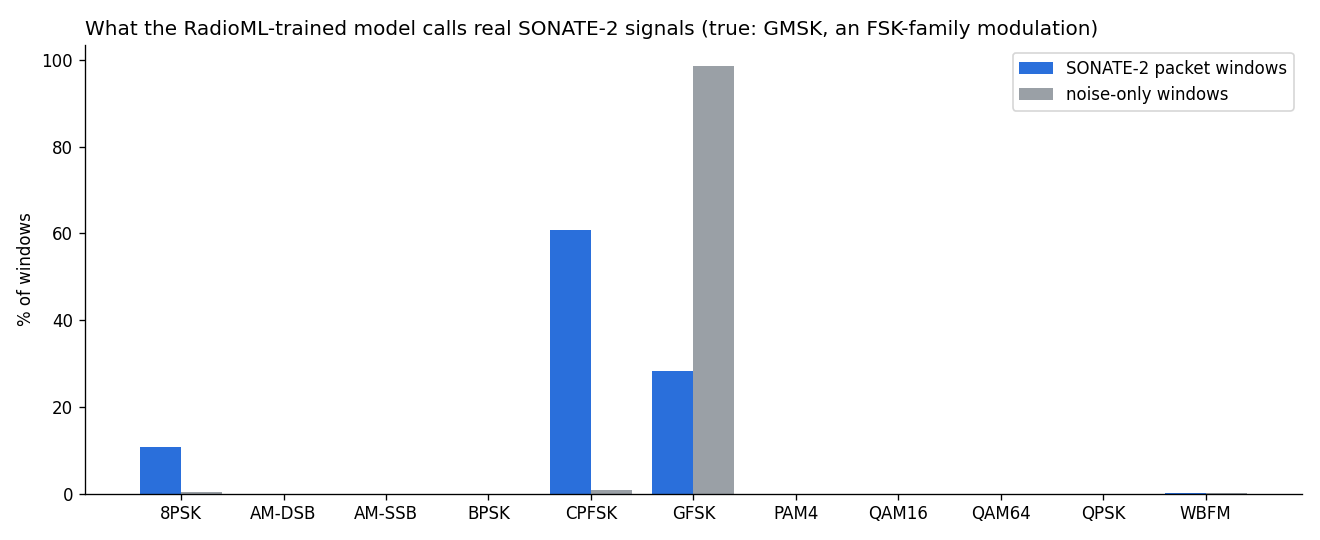

In [16]:
for f in ["results/spectrum_15104225.png", "results/stress_test.png", "results/radioml_transfer.png"]:
    display(Image(f))